# Weeks 2–3 playground · classic optimization, pushed until it breaks

The class code runs each method once on a friendly example. This notebook re-implements every method from scratch with NumPy, then asks what happens when you change the knobs: the learning rate, the starting point, the shape of the function.

Notes for this unit: [`notes.md`](notes.md). The class notebooks this builds on: [`01-classic-optimization-1d`](class-code/01-classic-optimization-1d.ipynb) (the pumpkin cannon) and [`02-multivariable-optimization`](class-code/02-multivariable-optimization.ipynb) (the surveyor's valley).

**Contents**
1. Is the answer on the slides right?
2. How slow is guess and check, really?
3. Can we predict exactly how many steps bisection needs?
4. What does the learning rate actually do?
5. Why does 2D gradient descent crawl, and when does it blow up?
6. Does Newton's method always find the minimum?
7. How much faster is Newton when the function isn't a parabola?
8. Is going derivative-free worth the cost on a hard valley?
9. What actually happens in the class "Try it yourself" challenges?
10. Your turn

**Sources:** the DCS 340 weeks 2–3 slides, the two class notebooks, and two resources linked from the slides: [Gradient Descent Unraveled](https://towardsdatascience.com/gradient-descent-unraveled-3274c895d12d) (Towards Data Science) and IntMath's [Newton's Method interactive graph](https://www.intmath.com/applications-differentiation/newtons-method-interactive.php).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({"figure.figsize": (7, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})
rng = np.random.default_rng(340)

In [2]:
# --- The functions used throughout ---

# 1D example from class: maximum at x = 2
f1   = lambda x: 4 - (x - 2)**2
df1  = lambda x: -2 * (x - 2)
d2f1 = lambda x: -2.0

# 2D example from class: g(x, y) = (x-2)^2 - xy + (y-3)^2
def g(v):
    x, y = v
    return (x - 2)**2 - x*y + (y - 3)**2

def grad_g(v):
    x, y = v
    return np.array([2*x - y - 4, -x + 2*y - 6])

H_g = np.array([[2.0, -1.0], [-1.0, 2.0]])   # constant Hessian

# A non-quadratic 1D function, so Newton can't cheat
f3   = lambda x: x**4 - 3*x**3 + 2
df3  = lambda x: 4*x**3 - 9*x**2          # = x^2 (4x - 9): critical points at 0 and 9/4
d2f3 = lambda x: 12*x**2 - 18*x

## 1. Is the answer on the slides right?

Two slides (Nelder–Mead and 2D Newton) say the minimum of $g$ is near $(2.33, 2.67)$. Setting the gradient to zero gives a linear system, $2x - y = 4$ and $-x + 2y = 6$, which we can solve exactly and compare against SciPy.

In [3]:
exact = np.linalg.solve(H_g, np.array([4.0, 6.0]))
nm    = minimize(g, x0=[0, 0], method="Nelder-Mead").x
slide = np.array([7/3, 8/3])

print(f"Exact solution of grad g = 0 : {exact.round(4)}   g = {g(exact):.4f}")
print(f"SciPy Nelder-Mead from (0,0)  : {nm.round(4)}   g = {g(nm):.4f}")
print(f"Point stated on the slides    : {slide.round(4)}   g = {g(slide):.4f}")
print(f"Hessian eigenvalues           : {np.linalg.eigvalsh(H_g)}  (both > 0, so it's a minimum)")

Exact solution of grad g = 0 : [4.6667 5.3333]   g = -12.3333
SciPy Nelder-Mead from (0,0)  : [4.6666 5.3333]   g = -12.3333
Point stated on the slides    : [2.3333 2.6667]   g = -6.0000
Hessian eigenvalues           : [1. 3.]  (both > 0, so it's a minimum)


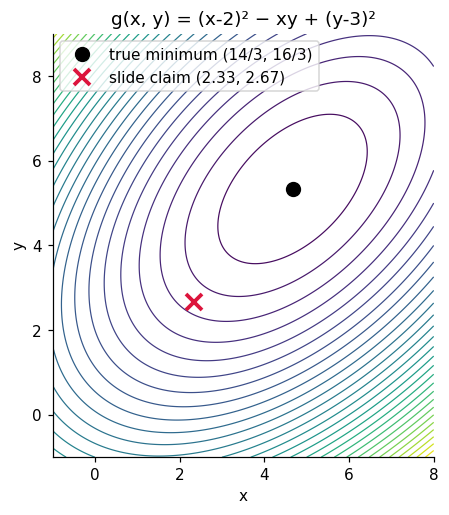

In [4]:
X, Y = np.meshgrid(np.linspace(-1, 8, 300), np.linspace(-1, 9, 300))
Z = g((X, Y))

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contour(X, Y, Z, levels=30, cmap="viridis", linewidths=0.8)
ax.plot(*exact, "o", ms=9, color="black", label="true minimum (14/3, 16/3)")
ax.plot(*slide, "x", ms=10, mew=2.5, color="crimson", label="slide claim (2.33, 2.67)")
ax.set(xlabel="x", ylabel="y", title="g(x, y) = (x-2)² − xy + (y-3)²")
ax.legend(loc="upper left"); ax.set_aspect("equal"); ax.grid(False)
plt.show()

The slide's point is on the slope, not at the bottom. Keep $(14/3, 16/3)$ as the target for the rest of the notebook.

## 2. How slow is guess and check, really?

Random search on $f_1$ over $[0, 4]$. How much does the error shrink as we throw more points at it?

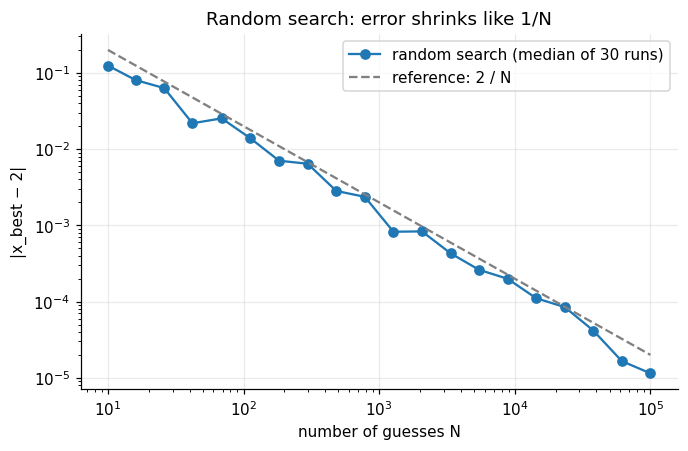

In [5]:
Ns = np.logspace(1, 5, 20).astype(int)
errors = []
for N in Ns:
    trials = [abs(xs[np.argmax(f1(xs))] - 2) for xs in (rng.uniform(0, 4, N) for _ in range(30))]
    errors.append(np.median(trials))

fig, ax = plt.subplots()
ax.loglog(Ns, errors, "o-", label="random search (median of 30 runs)")
ax.loglog(Ns, 2 / Ns, "--", color="gray", label="reference: 2 / N")
ax.set(xlabel="number of guesses N", ylabel="|x_best − 2|", title="Random search: error shrinks like 1/N")
ax.legend(); plt.show()

10× more guesses buys only 10× more accuracy. Getting 6 correct digits would take about a million evaluations, and in 2D you'd need that many *per axis*. Every method below exists to beat this.

## 3. Can we predict exactly how many steps bisection needs?

Because the bracket halves every step, we can predict the number of steps before running: $n = \lceil \log_2((b-a)/\text{tol}) \rceil$.

root = 2.0000000037 after 28 steps (predicted ≤ 29)


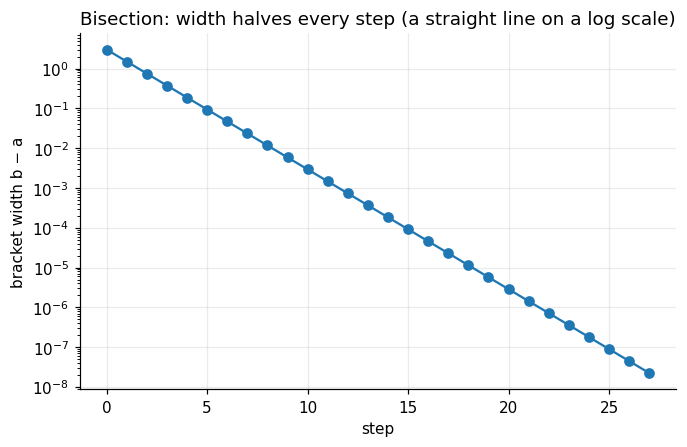

In [6]:
def bisection(df, a, b, tol=1e-8, max_iter=200):
    assert df(a) * df(b) < 0, "f' must change sign on [a, b]"
    history = []
    for _ in range(max_iter):
        c = (a + b) / 2
        history.append((a, b, c))
        if abs(df(c)) < tol or (b - a) / 2 < tol:
            break
        if np.sign(df(c)) == np.sign(df(a)):
            a = c
        else:
            b = c
    return c, history

a0, b0, tol = 0.0, 3.0, 1e-8
root, hist = bisection(df1, a0, b0, tol)
predicted = int(np.ceil(np.log2((b0 - a0) / tol)))
print(f"root = {root:.10f} after {len(hist)} steps (predicted ≤ {predicted})")

widths = [b - a for a, b, _ in hist]
fig, ax = plt.subplots()
ax.semilogy(widths, "o-")
ax.set(xlabel="step", ylabel="bracket width b − a", title="Bisection: width halves every step (a straight line on a log scale)")
plt.show()

## 4. What does the learning rate actually do?

The class example used $\alpha = 0.1$. For this parabola, the update is $x_{n+1} - 2 = (1 - 2\alpha)(x_n - 2)$, so the error is multiplied by $(1 - 2\alpha)$ each step. That predicts five different behaviors:

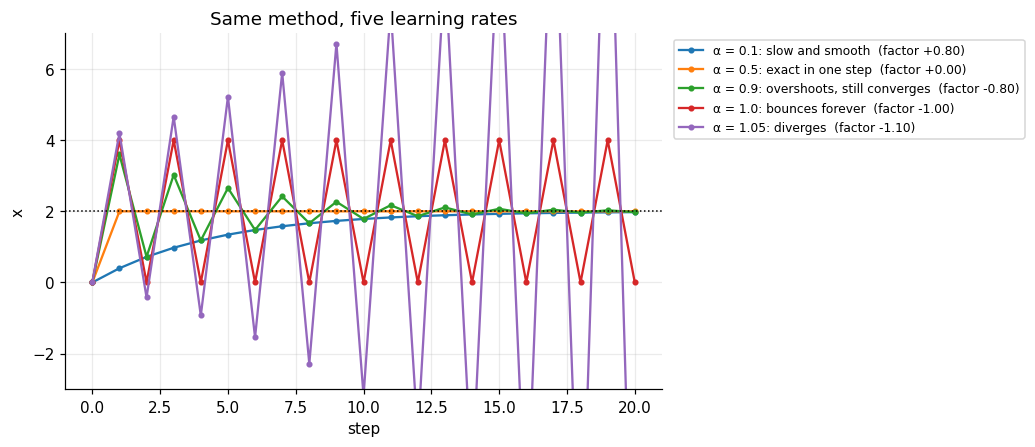

In [7]:
def gradient_ascent_1d(df, x0, alpha, steps):
    xs = [x0]
    for _ in range(steps):
        xs.append(xs[-1] + alpha * df(xs[-1]))
    return np.array(xs)

cases = {0.1: "slow and smooth", 0.5: "exact in one step", 0.9: "overshoots, still converges",
         1.0: "bounces forever", 1.05: "diverges"}

fig, ax = plt.subplots()
for alpha, label in cases.items():
    xs = gradient_ascent_1d(df1, x0=0.0, alpha=alpha, steps=20)
    ax.plot(xs, "o-", ms=3, label=f"α = {alpha}: {label}  (factor {1 - 2*alpha:+.2f})")
ax.axhline(2, color="black", lw=1, ls=":")
ax.set(xlabel="step", ylabel="x", ylim=(-3, 7), title="Same method, five learning rates")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1)); plt.show()

The "best" learning rate here is $\alpha = 0.5 = 1/|f''|$. That's exactly the step Newton's method would take, which is the bridge to section 6.

> **My take:** _Before running this, which learning rate did you expect to be best? What does the (1 − 2α) factor explain that the class notebook's single run at 0.2 didn't show?_

## 5. Why does 2D gradient descent crawl, and when does it blow up?

The Hessian of $g$ has eigenvalues 1 and 3. Theory says gradient descent is stable only for $\alpha < 2/\lambda_{\max} = 2/3$, and that the smallest eigenvalue sets how slowly the last stretch goes.

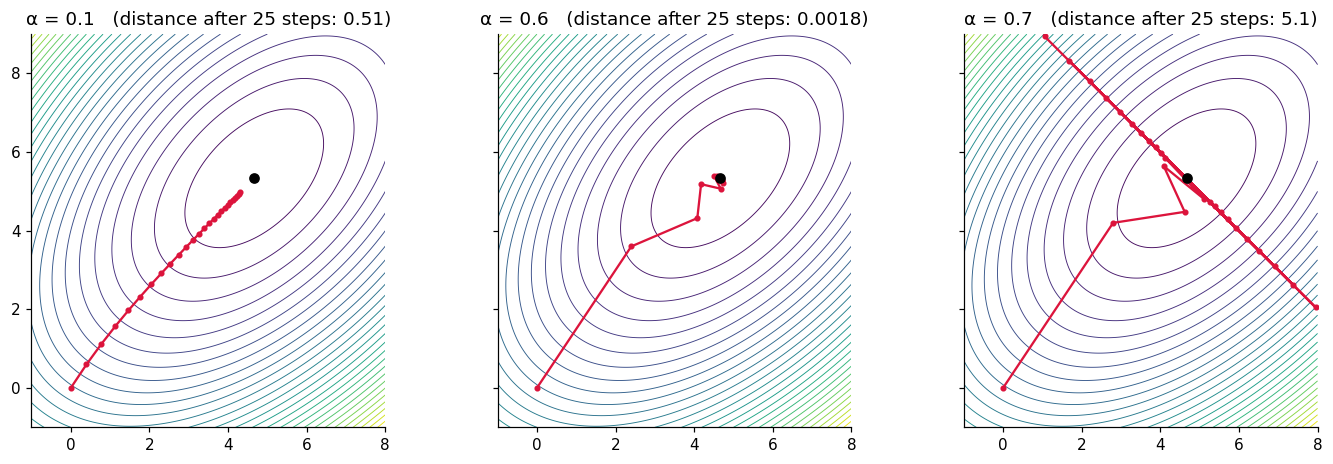

Class settings (α = 0.1, 20 steps) end at [4.059 4.725], target [4.667 5.333]


In [8]:
def gradient_descent(grad, v0, alpha, steps):
    vs = [np.array(v0, dtype=float)]
    for _ in range(steps):
        vs.append(vs[-1] - alpha * grad(vs[-1]))
    return np.array(vs)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharey=True)
for ax, alpha in zip(axes, [0.1, 0.6, 0.7]):
    path = gradient_descent(grad_g, [0, 0], alpha, steps=25)
    ax.contour(X, Y, Z, levels=30, cmap="viridis", linewidths=0.6)
    ax.plot(path[:, 0], path[:, 1], "o-", ms=3, color="crimson")
    ax.plot(*exact, "o", color="black")
    dist = np.linalg.norm(path[-1] - exact)
    ax.set(title=f"α = {alpha}   (distance after 25 steps: {dist:.2g})", xlim=(-1, 8), ylim=(-1, 9))
    ax.set_aspect("equal"); ax.grid(False)
plt.tight_layout(); plt.show()

path = gradient_descent(grad_g, [0, 0], 0.1, steps=20)
print(f"Class settings (α = 0.1, 20 steps) end at {path[-1].round(3)}, target {exact.round(3)}")

With $\alpha = 0.1$ the path heads straight for the valley, then crawls along it. That crawl is the eigenvalue-1 direction, where the error shrinks by only $1 - 0.1 \cdot 1 = 0.9$ per step. At $\alpha = 0.6$ it zig-zags across the valley but gets there; at $0.7$ (just past $2/3$) the zig-zag grows and the method blows up.

## 6. Does Newton's method always find the minimum?

On a quadratic, Newton is exact in one step. The interesting question is what happens on a function that isn't quadratic. Here's $f_3(x) = x^4 - 3x^3 + 2$, whose critical points are $x = 0$ (a flat inflection point, **not** a minimum) and $x = 9/4$ (the minimum).

In [9]:
def newton_1d(df, d2f, x0, steps=30, tol=1e-12):
    xs = [x0]
    for _ in range(steps):
        curv = d2f(xs[-1])
        if curv == 0:
            print(f"  f'' = 0 at x = {xs[-1]}: Newton can't take a step")
            break
        xs.append(xs[-1] - df(xs[-1]) / curv)
        if abs(xs[-1] - xs[-2]) < tol:
            break
    return np.array(xs)

print("Class function, any start → one step:")
for x0 in [-5.0, 0.0, 7.0]:
    print(f"  x0 = {x0:5}: {newton_1d(df1, d2f1, x0)[:3]}")

print("\n2D, one step from (0, 0):", (np.zeros(2) - np.linalg.solve(H_g, grad_g(np.zeros(2)))).round(4))

print("\nNon-quadratic f3, different starts:")
for x0 in [3.0, 1.0, 0.5]:
    xs = newton_1d(df3, d2f3, x0)
    print(f"  x0 = {x0}: ends at x = {xs[-1]:.6f} after {len(xs)-1} steps, f'' there = {d2f3(xs[-1]):.3g}")

Class function, any start → one step:
  x0 =  -5.0: [-5.  2.  2.]
  x0 =   0.0: [0. 2. 2.]
  x0 =   7.0: [7. 2. 2.]

2D, one step from (0, 0): [4.6667 5.3333]

Non-quadratic f3, different starts:
  x0 = 3.0: ends at x = 2.250000 after 7 steps, f'' there = 20.2
  x0 = 1.0: ends at x = 0.000000 after 30 steps, f'' there = -5.16e-09
  x0 = 0.5: ends at x = 0.000000 after 30 steps, f'' there = -6.32e-09


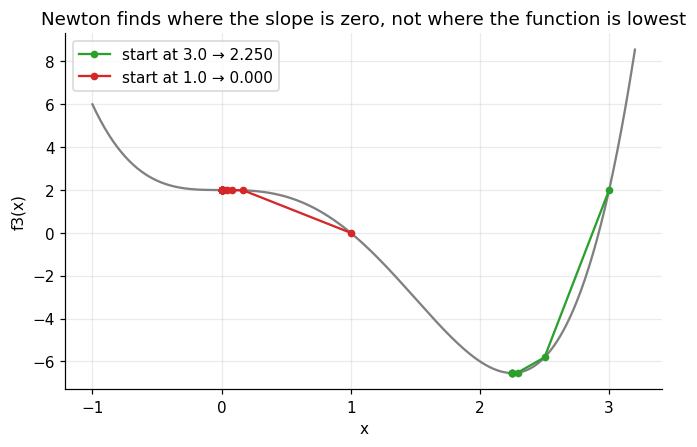

In [10]:
xx = np.linspace(-1, 3.2, 400)
fig, ax = plt.subplots()
ax.plot(xx, f3(xx), color="gray")
for x0, col in [(3.0, "tab:green"), (1.0, "tab:red")]:
    xs = newton_1d(df3, d2f3, x0)
    ax.plot(xs, f3(xs), "o-", ms=4, color=col, label=f"start at {x0} → {xs[-1]:.3f}")
ax.set(xlabel="x", ylabel="f3(x)", title="Newton finds where the slope is zero, not where the function is lowest")
ax.legend(); plt.show()

Starting at 3, Newton reaches the true minimum at $9/4$ in 7 steps. Starting at 1 or 0.5, it heads to $x = 0$ instead: a flat inflection point that isn't a minimum at all. Two lessons are hiding here:

- At both of those starting points $f'' < 0$, so locally the curve bends like a *maximum*. Newton doesn't know whether you want a min or a max; it just jumps to where the tangent line of $f'$ crosses zero.
- It never quite arrives: after 30 steps it's still creeping. Near $x = 0$, $f''$ shrinks toward zero, which is exactly the failure case from the slides, and the fast quadratic convergence disappears.

IntMath's interactive graph, linked from the Newton visualization slide, shows the same crawl from the root-finding side: Newton on $f(x) = x^2$ is still far from the root after 12 steps. It's the same cause. Here Newton is really solving $f_3'(x) = x^2(4x - 9) = 0$, and $x = 0$ is a double root of that equation, exactly like the root of $x^2$.

> **My take:** _The slides say Newton converges quadratically. When is that true, and when isn't it? Connect this to something from class discussion._

## 7. How much faster is Newton when the function isn't a parabola?

All three 1D methods, hunting for the minimum of $f_3$ at $x^* = 9/4$. The y-axis is the error on a log scale, so a straight line means linear convergence and a curve that dives means quadratic.

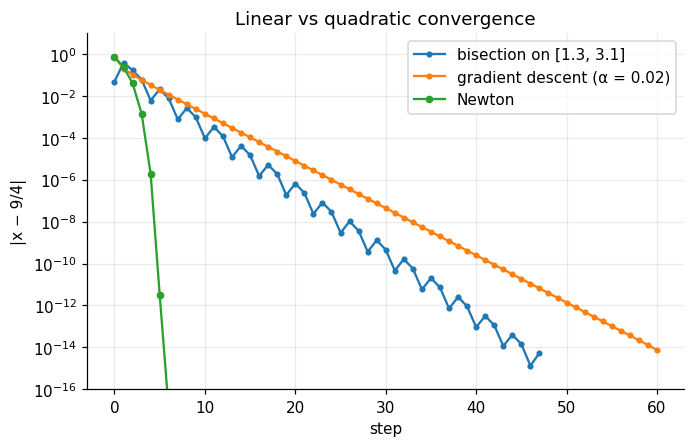

Newton            reaches 1e-10 accuracy at step 5
Bisection         reaches 1e-10 accuracy at step 31
Gradient descent  reaches 1e-10 accuracy at step 42


In [11]:
x_star = 9 / 4

_, bis_hist = bisection(df3, 1.3, 3.1, tol=1e-14)
bis_err = [abs(c - x_star) for *_, c in bis_hist]

gd = [3.0]
for _ in range(60):
    gd.append(gd[-1] - 0.02 * df3(gd[-1]))
gd_err = np.abs(np.array(gd) - x_star)

nt_err = np.abs(newton_1d(df3, d2f3, 3.0) - x_star)

fig, ax = plt.subplots()
ax.semilogy(bis_err, "o-", ms=3, label="bisection on [1.3, 3.1]")
ax.semilogy(gd_err, "o-", ms=3, label="gradient descent (α = 0.02)")
ax.semilogy(nt_err + 1e-17, "o-", ms=4, label="Newton")
ax.set(xlabel="step", ylabel="|x − 9/4|", ylim=(1e-16, 10), title="Linear vs quadratic convergence")
ax.legend(); plt.show()

for name, err in [("Newton", nt_err), ("Bisection", bis_err), ("Gradient descent", gd_err)]:
    hit = next((i for i, e in enumerate(err) if e < 1e-10), None)
    print(f"{name:17s} reaches 1e-10 accuracy at step {hit}")

Newton's error dives off a cliff (the number of correct digits roughly doubles each step). Bisection and gradient descent are straight lines: steady, but each step buys the same fixed fraction of improvement.

## 8. Is going derivative-free worth the cost on a hard valley?

The class example was a friendly bowl. The Rosenbrock function $r(x, y) = (1 - x)^2 + 100(y - x^2)^2$ is a standard stress test: a long, curved, nearly flat valley with the minimum at $(1, 1)$. Here we count how many times each method has to evaluate the function.

Nelder-Mead : [1. 1.]  function evaluations = 219
BFGS        : [1. 1.]  function evaluations = 39 (+ gradient evaluations = 39)


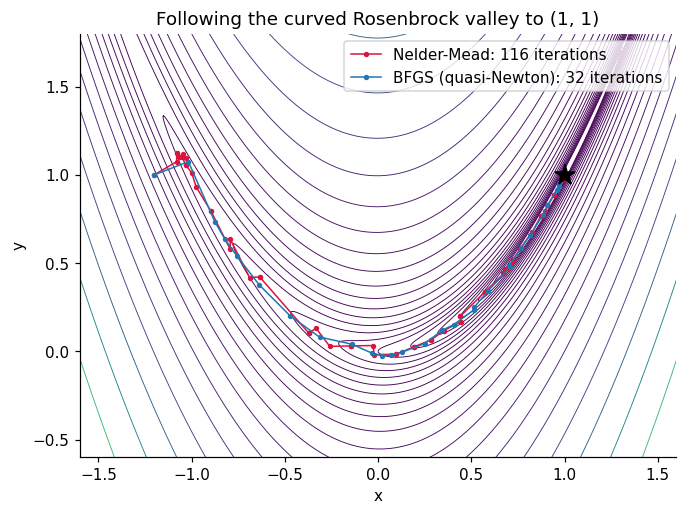

In [12]:
rosen = lambda v: (1 - v[0])**2 + 100 * (v[1] - v[0]**2)**2
rosen_grad = lambda v: np.array([-2*(1 - v[0]) - 400*v[0]*(v[1] - v[0]**2), 200*(v[1] - v[0]**2)])
x0 = [-1.2, 1.0]

nm_path = [np.array(x0)]
res_nm = minimize(rosen, x0, method="Nelder-Mead", callback=lambda xk: nm_path.append(xk.copy()),
                  options={"xatol": 1e-8, "fatol": 1e-8})
bfgs_path = [np.array(x0)]
res_bfgs = minimize(rosen, x0, jac=rosen_grad, method="BFGS", callback=lambda xk: bfgs_path.append(xk.copy()))

print(f"Nelder-Mead : {res_nm.x.round(6)}  function evaluations = {res_nm.nfev}")
print(f"BFGS        : {res_bfgs.x.round(6)}  function evaluations = {res_bfgs.nfev} (+ gradient evaluations = {res_bfgs.njev})")

RX, RY = np.meshgrid(np.linspace(-1.6, 1.6, 400), np.linspace(-0.6, 1.8, 400))
fig, ax = plt.subplots(figsize=(7, 5))
ax.contour(RX, RY, rosen((RX, RY)), levels=np.logspace(-1, 3, 25), cmap="viridis", linewidths=0.6)
for path, label, col in [(np.array(nm_path), "Nelder-Mead", "crimson"), (np.array(bfgs_path), "BFGS (quasi-Newton)", "tab:blue")]:
    ax.plot(path[:, 0], path[:, 1], "o-", ms=2.5, lw=1, color=col, label=f"{label}: {len(path)-1} iterations")
ax.plot(1, 1, "*", ms=14, color="black")
ax.set(xlabel="x", ylabel="y", title="Following the curved Rosenbrock valley to (1, 1)")
ax.legend(); ax.grid(False); plt.show()

Both find $(1, 1)$, but Nelder–Mead needs several times as many function evaluations because it has to discover the downhill direction by poking around. BFGS gets the direction from the gradient and builds up an estimate of the curvature as it goes, a practical middle ground between gradient descent and full Newton.

## 9. What actually happens in the class "Try it yourself" challenges?

Both class notebooks end with "Try it yourself" prompts. Here are all four, actually run, with what happens and why.

### Pumpkin challenge: change the flight to $f(x) = 10 - (x - 5)^2$

The class functions read the global `df` and `ddf`, so a new pumpkin means rewriting three functions by hand. Passing the derivative in as an argument fixes that once. These are the class versions, unchanged except for that:

In [13]:
def class_gradient_ascent(df, start_x, learning_rate=0.2, steps=20):
    x = start_x
    for _ in range(steps):
        x = x + learning_rate * df(x)
    return x

def class_bisection(df, a, b, tolerance=0.01):
    if df(a) * df(b) > 0:
        return None                       # no sign change: peak not bracketed
    while (b - a) / 2 > tolerance:
        midpoint = (a + b) / 2
        if df(midpoint) == 0:
            return midpoint
        elif df(a) * df(midpoint) < 0:
            b = midpoint
        else:
            a = midpoint
    return (a + b) / 2

def class_newton(df, ddf, start_x, iterations=5):
    x = start_x
    for _ in range(iterations):
        x = x - df(x) / ddf(x)
    return x

new_df  = lambda x: -2 * (x - 5)
new_ddf = lambda x: -2.0
shifted_df = lambda x: -2 * (x - 5.1)     # same pumpkin, peak nudged to 5.1

print(f"Gradient ascent from 0.1        : {class_gradient_ascent(new_df, 0.1):.4f}")
print(f"Newton from 0.5                 : {class_newton(new_df, new_ddf, 0.5):.4f}")
print(f"Bisection on the class's [0, 5] : {class_bisection(new_df, 0, 5):.4f}")
print(f"Bisection on [0, 10]            : {class_bisection(new_df, 0, 10):.4f}")
print(f"Peak at 5.1, bracket [0, 5]     : {class_bisection(shifted_df, 0, 5)}")

Gradient ascent from 0.1        : 4.9998
Newton from 0.5                 : 5.0000
Bisection on the class's [0, 5] : 4.9902
Bisection on [0, 10]            : 5.0000
Peak at 5.1, bracket [0, 5]     : None


Everything finds 5, but bisection only just gets away with it. The new peak sits exactly on the edge of the class's bracket $[0, 5]$. The sign check passes only because $f'(5) = 0$ makes the product zero rather than positive, and the answer creeps toward the edge (4.990). Nudge the peak to 5.1 and the same bracket is rejected outright. The lesson: bracket with room on both sides.

### Surveyor challenges 1 and 2: start at $[10, 10]$; try learning rates 0.8 and 0.001

In [14]:
def class_gd(start, learning_rate, steps=50):
    position = np.array(start, dtype=float)
    for _ in range(steps):
        position = position - learning_rate * grad_g(position)
    return position

newton_from_10 = np.array([10.0, 10.0]) - np.linalg.solve(H_g, grad_g(np.array([10.0, 10.0])))

print(f"GD from [10, 10], rate 0.1   : {class_gd([10, 10], 0.1).round(2)}")
print(f"Newton from [10, 10], 1 step : {newton_from_10.round(2)}")
print(f"GD from [0, 0],  rate 0.8    : {class_gd([0, 0], 0.8).round(0)}")
print(f"GD from [0, 0],  rate 0.001  : {class_gd([0, 0], 0.001).round(2)}")

steps_needed = np.log(1000) / -np.log(1 - 0.001 * 1)   # slow direction has curvature 1
print(f"\nSteps for rate 0.001 to shrink the error 1000x: about {steps_needed:,.0f}")

GD from [10, 10], rate 0.1   : [4.69 5.36]
Newton from [10, 10], 1 step : [4.67 5.33]
GD from [0, 0],  rate 0.8    : [ 6749643. -6749633.]
GD from [0, 0],  rate 0.001  : [0.2  0.29]

Steps for rate 0.001 to shrink the error 1000x: about 6,904


- **Starting at $[10, 10]$** barely matters on a bowl this simple: gradient descent gets close in 50 steps, and Newton lands exactly in one step from anywhere, because the surface is quadratic.
- **Rate 0.8** is past the $2/\lambda_{\max} = 2/3$ limit from section 5, so every step overshoots by more than the last. After 50 steps the "answer" is in the millions.
- **Rate 0.001** is perfectly stable and uselessly slow. After 50 steps it has barely left the start, and it would need about 7,000 steps to get close.

### Surveyor challenge 3: change the terrain to $x^2 + y^2$. Does the code still work?

Change only `f`, as the prompt suggests, and run each method. (I start at $[3, -2]$: the class's starting point $[0, 0]$ is already the bottom of this new bowl, which would hide everything.)

In [15]:
new_terrain = lambda v: v[0]**2 + v[1]**2    # true minimum: (0, 0)
start = np.array([3.0, -2.0])

nm_new = minimize(new_terrain, start, method="Nelder-Mead").x
gd_stale = class_gd(start, 0.1)                                # still uses the old gradient
newton_stale = start - np.linalg.solve(H_g, grad_g(start))     # still uses the old gradient and Hessian

print(f"Nelder-Mead          : {nm_new.round(3)}")
print(f"Gradient descent     : {gd_stale.round(3)}")
print(f"Newton               : {newton_stale.round(3)}")

Nelder-Mead          : [ 0. -0.]
Gradient descent     : [4.643 5.31 ]
Newton               : [4.667 5.333]


Only Nelder–Mead notices the new terrain. Gradient descent and Newton never call `f` at all: they only use the hand-written `gradient()` and `hessian`, which still describe the old valley. So they confidently return the old answer, $(4.67, 5.33)$, with no error message. It's a silent bug, the worst kind.

**The fix:** compute the derivatives from `f` itself with finite differences, so changing `f` is the only edit needed.

In [16]:
def numerical_gradient(f, v, h=1e-6):
    v = np.asarray(v, dtype=float)
    return np.array([(f(v + h*e) - f(v - h*e)) / (2*h) for e in np.eye(len(v))])

def numerical_hessian(f, v, h=1e-4):
    v = np.asarray(v, dtype=float)
    cols = [(numerical_gradient(f, v + h*e) - numerical_gradient(f, v - h*e)) / (2*h) for e in np.eye(len(v))]
    H = np.column_stack(cols)
    return (H + H.T) / 2                      # clean up rounding so it's symmetric

def gd_any(f, start, learning_rate=0.1, steps=200):
    v = np.array(start, dtype=float)
    for _ in range(steps):
        v = v - learning_rate * numerical_gradient(f, v)
    return v

def newton_any(f, start, iterations=5):
    v = np.array(start, dtype=float)
    for _ in range(iterations):
        v = v - np.linalg.solve(numerical_hessian(f, v), numerical_gradient(f, v))
    return v

for name, terrain in [("class terrain", g), ("x^2 + y^2", new_terrain)]:
    print(f"{name:14s} GD: {gd_any(terrain, start).round(3)}   Newton: {newton_any(terrain, start).round(3)}")

check_point = np.array([1.3, -0.7])
err = np.abs(numerical_gradient(g, check_point) - grad_g(check_point)).max()
print(f"\nNumerical vs hand-written gradient at {check_point}: max difference {err:.1e}")

class terrain  GD: [4.667 5.333]   Newton: [4.667 5.333]
x^2 + y^2      GD: [ 0. -0.]   Newton: [-0. -0.]

Numerical vs hand-written gradient at [ 1.3 -0.7]: max difference 4.7e-10


Now both methods follow whatever `f` says. The cost: every numerical gradient takes 2 function evaluations per dimension (and the Hessian many more), and finite differences trade a little precision for convenience. Libraries like JAX and PyTorch solve this properly with *automatic differentiation*, which computes exact derivatives from the code of `f` itself.

> **My take:** _Which of the four challenge results surprised you most, and why? The silent bug in challenge 3: how would you have noticed it without comparing against Nelder–Mead?_

## 10. Your turn

Write these in your own words; this is the part of the portfolio that shows how you think.

**What surprised me:**

> _…_

**What I'd explain differently to a classmate:**

> _…_

**Ideas to try next** (pick one and add a section):
- Add *momentum* to gradient descent and rerun section 5. Does it fix the crawl along the valley?
- Run Newton on Himmelblau's function, which has four minima. Map which starting points lead to which minimum.
- Replace the fixed $\alpha$ with a *backtracking line search* and compare it to the learning-rate sweep in section 4.
- Connect it to your own work: the review cited on slide 2 is about optimization in water resources engineering. A small water-allocation problem on the Amu Darya (irrigation versus inflow to the Aral Sea) would tie this module to the rest of your portfolio.